<a href="https://colab.research.google.com/github/keerthanasree-v/movie-rating-prediction/blob/main/Movie_Rating_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Using Colab cache for faster access to the 'movie-ratings' dataset.
Downloaded dataset at: /kaggle/input/movie-ratings

Dataset preview:
   Movie_ID    Title   Genre  Rating
0         1  Movie_1  Action     3.2
1         2  Movie_2  Horror     3.4
2         3  Movie_3  Comedy     1.5
3         4  Movie_4   Drama     2.5
4         5  Movie_5  Comedy     2.1

Checking missing values:
Movie_ID    0
Title       0
Genre       0
Rating      0
dtype: int64

Model results:
MAE: 1.0171835477611508
R2 score: -0.01189866370033621


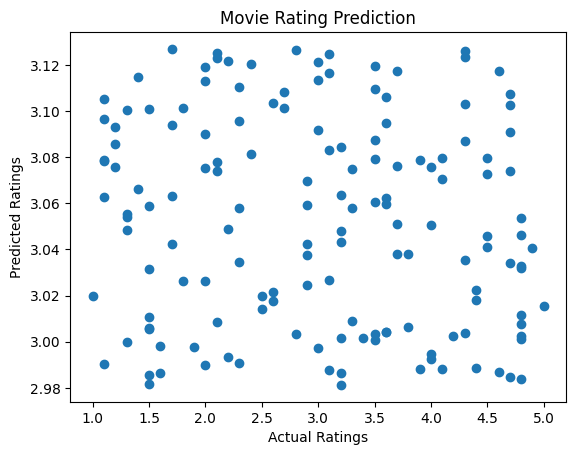

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import os

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

import kagglehub

data_path = kagglehub.dataset_download("navneetkaurbrarr/movie-ratings")
print("Downloaded dataset at:", data_path)

data = pd.read_csv(os.path.join(data_path, "movie_ratings.csv"))

print("\nDataset preview:")
print(data.head())

print("\nChecking missing values:")
print(data.isnull().sum())

data = data.dropna()

data = data.select_dtypes(include=['int64', 'float64'])

X = data.drop("Rating", axis=1)
y = data["Rating"]


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)


model = LinearRegression()
model.fit(X_train, y_train)


predictions = model.predict(X_test)

print("\nModel evaluation results:")
print("MAE:", mean_absolute_error(y_test, predictions))
print("R2 score:", r2_score(y_test, predictions))

plt.scatter(y_test, predictions)
plt.xlabel("Actual Ratings")
plt.ylabel("Predicted Ratings")
plt.title("Movie Rating Prediction")
plt.show()
